# Etapa 2 — Cluster Jerárquico (Ward)

**TPI Ciencia de Datos — DS Airlines**

Este notebook implementa la técnica de **Cluster Jerárquico Aglomerativo (método Ward)** sobre los **30.518 clientes únicos** afectados por los 659 vuelos predichos como demorados (hoja `clientes_a_analizar` de `resultados_etapa2_arbol.xlsx`, generado por `04_Aplicacion_Arbol_CasosNuevos.ipynb`).

**Objetivo:** caracterizar a los pasajeros afectados en perfiles diferenciados y comparar la segmentación con la de K-Medias, de modo que pueda alimentar al agente inteligente para decidir qué beneficio compensatorio asignar a cada cliente (voucher de comida o acceso a sala VIP).

**Pipeline:**

1. Carga del dataset y construcción de la vista minable (z-score sobre 6 variables numéricas).
2. Aplicación del Cluster Jerárquico Ward sobre una muestra aleatoria de 5.000 registros (necesario por restricciones de memoria, ver justificación más abajo).
3. Selección del número de clusters mediante dendrograma + silhouette.
4. Aglomeración de la muestra con K elegido y cálculo de centroides.
5. Asignación de los 30.518 clientes al cluster del centroide más cercano.
6. Caracterización de los clusters mediante variables categóricas.
7. Visualización en el plano de las dos primeras componentes principales.
8. Análisis de sensibilidad de la segmentación a la muestra elegida.

## 1. Importaciones y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist

# Reproducibilidad (semilla coherente con la utilizada en la fase de clasificación)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuración visual
plt.rcParams['figure.dpi'] = 100


## 2. Carga del dataset y construcción de la vista minable

Se carga la hoja `clientes_a_analizar` del archivo `resultados_etapa2_arbol.xlsx`, generado por el notebook 04, y se construye la vista minable definida en la fase de Preparación de los Datos: **seis variables numéricas estandarizadas z-score** (`edad`, `cant_vuelos`, `cantidad_millas`, `ingreso_mensual`, `anticipacion_compra_promedio`, `gasto_acumulado`).

Las variables categóricas (`ocupacion`, `clase_preferida`, `programaMillas`, `canal_compra`) se conservan en el dataset original para la caracterización posterior de los clusters, pero no entran al modelado dado que el algoritmo opera sobre distancias euclídeas.

La identificación del cliente (`id_cliente`) se conserva en una columna paralela para trazabilidad sobre el reporte final.

In [2]:
clientes = pd.read_excel('resultados_etapa2_arbol.xlsx', sheet_name='clientes_a_analizar')
print(f'Dataset cargado: {clientes.shape}')
clientes.head(3)


Dataset cargado: (30518, 14)


,id_cliente,sexo,provincia,edad,ocupacion,cant_vuelos,clase_preferida,gasto_acumulado,gasto_acumulado_extra,programaMillas,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,canal_compra
0,1,M,Salta,24,Comerciante,21,Económica,5731.62,1222.62,Sí,19113,1367,3,Agencia
1,2,F,Córdoba,49,Médico,16,Económica,2593.40,510.70,No,0,6252,30,App
2,3,M,Buenos Aires,41,Docente,10,Económica,2850.62,627.01,No,0,1593,16,App


In [3]:
# Variables que entran al modelado
vars_modelado = ['edad', 'cant_vuelos', 'cantidad_millas', 'ingreso_mensual',
                 'anticipacion_compra_promedio', 'gasto_acumulado']

# Trazabilidad
ids = clientes['id_cliente'].copy()

# Estandarización z-score
scaler = StandardScaler()
X_std = pd.DataFrame(
    scaler.fit_transform(clientes[vars_modelado]),
    columns=vars_modelado
)

print('Verificación z-score (media ≈ 0, desvío ≈ 1):')
print(X_std.describe().round(3).loc[['mean', 'std']])


Verificación z-score (media ≈ 0, desvío ≈ 1):
      edad  cant_vuelos  cantidad_millas  ingreso_mensual  \
mean   0.0          0.0             -0.0              0.0   
std    1.0          1.0              1.0              1.0   

      anticipacion_compra_promedio  gasto_acumulado  
mean                          -0.0              0.0  
std                            1.0              1.0  


## 3. Muestreo para el cálculo del dendrograma

El Cluster Jerárquico Aglomerativo en su implementación clásica (SciPy) requiere construir y mantener en memoria la matriz de distancias completa entre todos los pares de observaciones. Para los 30.518 clientes esto implicaría aproximadamente 7,5 GB de RAM (matriz densa de 30.518 × 30.518 valores en `float64`), lo que excede los recursos disponibles en entornos estándar.

El abordaje seguido es la **estrategia de muestreo + asignación al centroide**, equivalente a la lógica que aplica SPSS Modeler internamente cuando se le suministra un dataset grande al nodo de Cluster Jerárquico:

1. Se toma una muestra aleatoria de 5.000 registros (semilla fija = 42).
2. Sobre esa muestra se construye el linkage Ward y el dendrograma, y se elige el número de clusters K.
3. Se aglomera la muestra con K, se calculan los centroides de cada cluster en el espacio z-score.
4. Se asignan los 30.518 registros al cluster cuyo centroide se encuentra más cerca (distancia euclídea).

Este abordaje preserva la estructura jerárquica del agrupamiento y permite aplicarla a todo el dataset sin perder validez metodológica.

In [4]:
SAMPLE_SIZE = 5000

sample_idx = np.random.choice(X_std.index, size=SAMPLE_SIZE, replace=False)
X_sample = X_std.loc[sample_idx].reset_index(drop=True)
print(f'Muestra para el dendrograma: {len(X_sample)} registros')


Muestra para el dendrograma: 5000 registros


## 4. Construcción del linkage y dendrograma

Se utiliza el **método Ward** con métrica euclídea. Ward minimiza el incremento de la suma de cuadrados intra-cluster en cada fusión, lo que tiende a generar clusters compactos y de tamaños similares. Es la elección estándar cuando las variables están estandarizadas y se busca una segmentación interpretable.


Calculando linkage Ward...


Linkage matrix: (4999, 4)


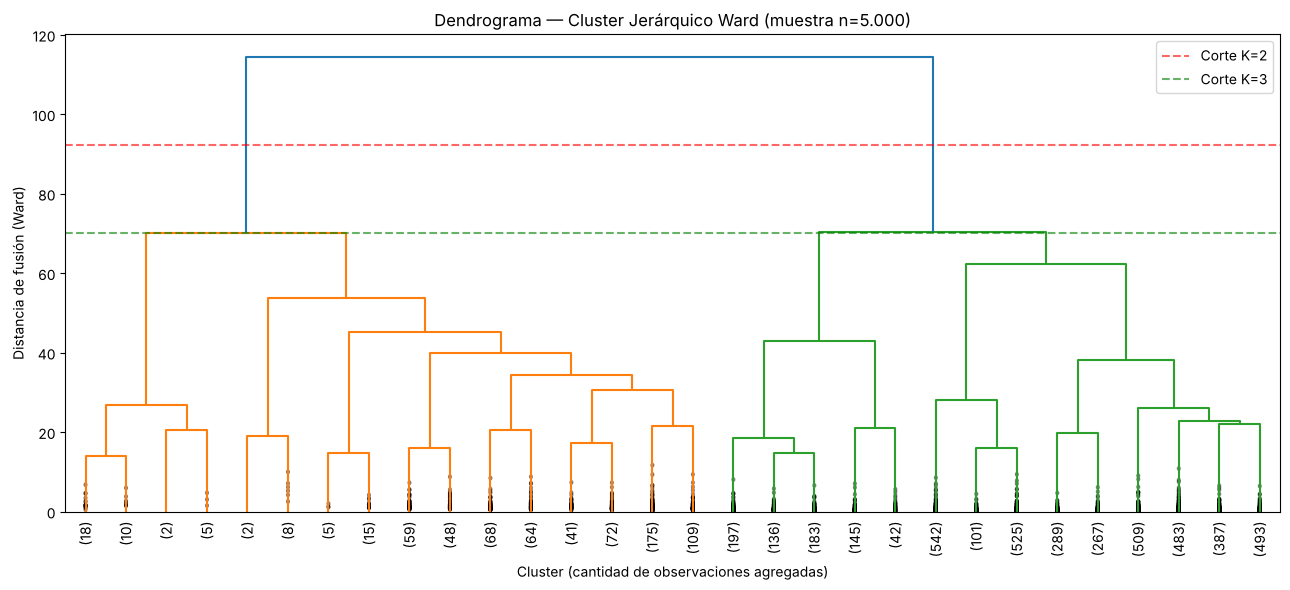

In [5]:
print('Calculando linkage Ward...')
Z = linkage(X_sample.values, method='ward', metric='euclidean')
print(f'Linkage matrix: {Z.shape}')

# Dendrograma truncado a las últimas 30 fusiones (legibilidad)
fig, ax = plt.subplots(figsize=(13, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=10, show_contracted=True, ax=ax)
ax.set_title('Dendrograma — Cluster Jerárquico Ward (muestra n=5.000)')
ax.set_xlabel('Cluster (cantidad de observaciones agregadas)')
ax.set_ylabel('Distancia de fusión (Ward)')
# Líneas de corte: punto medio entre las distancias de fusión que separan cada K
corte_k2 = (Z[-1, 2] + Z[-2, 2]) / 2
corte_k3 = (Z[-2, 2] + Z[-3, 2]) / 2
ax.axhline(y=corte_k2, color='red', linestyle='--', alpha=0.6, label='Corte K=2')
ax.axhline(y=corte_k3, color='green', linestyle='--', alpha=0.6, label='Corte K=3')
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
# Análisis de las distancias de fusión para detectar saltos significativos
print('Últimas 10 fusiones (orden ascendente de distancia):')
print(f'{"Fusión":>10} {"Distancia Ward":>16} {"Salto absoluto":>16}')
dist_fus = Z[:, 2]
for i in range(10, 0, -1):
    delta = dist_fus[-i] - dist_fus[-i-1] if i < 10 else 0
    print(f'{len(Z)-i+1:>10} {dist_fus[-i]:>16.2f} {delta:>16.2f}')


Últimas 10 fusiones (orden ascendente de distancia):
    Fusión   Distancia Ward   Salto absoluto
      4990            34.38             0.00
      4991            38.15             3.76
      4992            39.92             1.77
      4993            42.90             2.98
      4994            45.33             2.44
      4995            53.75             8.42
      4996            62.37             8.61
      4997            70.06             7.70
      4998            70.43             0.36
      4999           114.37            43.94


## 5. Selección del número de clusters

Se complementa el análisis del dendrograma con dos métricas de calidad: el **coeficiente de Silhouette** (mide cuán similar es cada observación a su cluster respecto del vecino más cercano; valores cercanos a 1 indican clusters bien separados) y el índice **Calinski-Harabasz** (razón entre la dispersión inter-cluster y la intra-cluster; valores más altos indican mejor separación).


In [7]:
resultados = []
for k in range(2, 9):
    labels_k = fcluster(Z, t=k, criterion='maxclust')
    sil = silhouette_score(X_sample.values, labels_k,
                           sample_size=3000, random_state=RANDOM_STATE)
    ch = calinski_harabasz_score(X_sample.values, labels_k)
    counts = pd.Series(labels_k).value_counts().sort_index().tolist()
    resultados.append({'K': k, 'silhouette': sil,
                       'calinski_harabasz': ch, 'tamaños': counts})

df_res = pd.DataFrame(resultados)
df_res


,K,silhouette,calinski_harabasz,tamaños
0,2,0.484536,1477.172787,"[701, 4299]"
1,3,0.272654,1146.977000,"[701, 703, 3596]"
2,4,0.278877,1111.343406,"[35, 666, 703, 3596]"
3,5,0.181126,1098.866480,"[35, 666, 703, 1168, 2428]"
4,6,0.185827,1075.437102,"[35, 10, 656, 703, 1168, 2428]"
5,7,0.190116,1034.997849,"[35, 10, 20, 636, 703, 1168, 2428]"
6,8,0.191469,1011.123554,"[35, 10, 20, 636, 516, 187, 1168, 2428]"


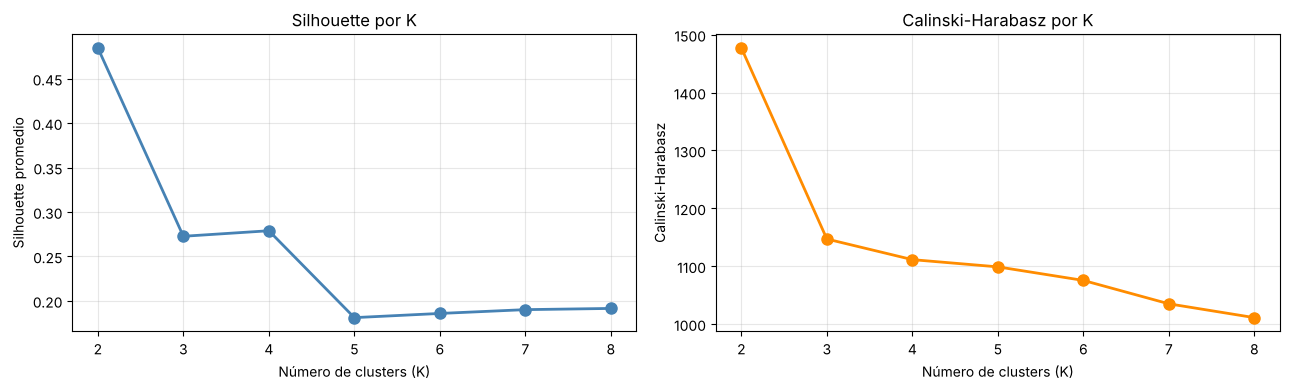

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_res['K'], df_res['silhouette'], 'o-',
             color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Silhouette promedio')
axes[0].set_title('Silhouette por K')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(2, 9))

axes[1].plot(df_res['K'], df_res['calinski_harabasz'], 'o-',
             color='darkorange', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Calinski-Harabasz')
axes[1].set_title('Calinski-Harabasz por K')
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(2, 9))

plt.tight_layout()
plt.show()


**Decisión sobre K.**

El dendrograma muestra un único salto de fusión muy marcado: al pasar de K=2 a K=1 la distancia sube de 70,43 a 114,37. En cambio, la fusión que lleva de K=3 a K=2 ocurre casi a la misma altura que la anterior (70,06 → 70,43), así que la banda de corte para K=3 es muy angosta. Mirado solo el dendrograma, la partición más natural es K=2.

El silhouette coincide: alcanza su máximo en K=2 (0,485) y baja a 0,273 en K=3. Sin embargo, el valor alto de K=2 corresponde a la separación trivial entre el subgrupo Premium (~14 % de la muestra) y el resto, sin discriminar perfiles intermedios. Calinski-Harabasz decrece monótonamente con K, sin un punto de inflexión claro.

Se selecciona **K = 3** como solución final, por dos motivos:

1. Es el primer valor de K que separa, además del Premium, dos perfiles no-Premium, y permite comparar directamente con K-Medias (k = 3).
2. K=4 tiene un silhouette apenas mayor (0,279), pero solo porque aísla un micro-cluster de 35 observaciones (0,7 % de la muestra). De K=5 a K=8 aparecen más grupos marginales de 10 a 20 observaciones: el algoritmo separa outliers en lugar de descubrir perfiles nuevos.

## 6. Aglomeración con K=3 y cálculo de centroides

In [9]:
K = 3
labels_sample = fcluster(Z, t=K, criterion='maxclust')

# Centroides en el espacio estandarizado (z-score)
centroides = np.array([
    X_sample.values[labels_sample == c].mean(axis=0)
    for c in sorted(np.unique(labels_sample))
])

print('Centroides (espacio z-score):')
df_centroides = pd.DataFrame(centroides, columns=X_std.columns,
                              index=[f'Cluster {i}' for i in range(1, K+1)])
df_centroides.round(3)


Centroides (espacio z-score):


,edad,cant_vuelos,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,gasto_acumulado
Cluster 1,0.140,1.760,1.267,0.980,-0.178,1.476
Cluster 2,0.407,-0.278,-0.217,-0.191,1.698,-0.245
Cluster 3,-0.089,-0.309,-0.213,-0.176,-0.295,-0.255


## 7. Asignación de los 30.518 clientes al cluster más cercano

In [10]:
# Distancia euclídea de cada cliente a cada centroide
distancias = cdist(X_std.values, centroides, metric='euclidean')
labels_full = distancias.argmin(axis=1) + 1  # etiquetas 1, 2, 3

# Construir dataset enriquecido
df_full = clientes.copy()
df_full['cluster_jerarquico'] = labels_full

print(f'Distribución de clusters sobre los {len(df_full):,} clientes:'.replace(',', '.'))
sz = df_full['cluster_jerarquico'].value_counts().sort_index()
for c, n in sz.items():
    print(f'  Cluster {c}: {n:>6} ({n/len(df_full)*100:>5.1f}%)')


Distribución de clusters sobre los 30.518 clientes:
  Cluster 1:   3599 ( 11.8%)
  Cluster 2:   4891 ( 16.0%)
  Cluster 3:  22028 ( 72.2%)


In [11]:
# Calidad de la segmentación sobre el dataset completo
sil_full = silhouette_score(X_std.values, labels_full,
                            sample_size=5000, random_state=RANDOM_STATE)
ch_full = calinski_harabasz_score(X_std.values, labels_full)
n_txt = f'{len(df_full):,}'.replace(',', '.')
print(f'Silhouette (n={n_txt}, sample=5.000): {sil_full:.4f}')
print(f'Calinski-Harabasz (n={n_txt}):        {ch_full:.1f}')


Silhouette (n=30.518, sample=5.000): 0.3016
Calinski-Harabasz (n=30.518):        7897.4


## 8. Caracterización de los clusters

### 8.1. Perfil numérico (medias en escala original)


In [12]:
perfil_num = df_full.groupby('cluster_jerarquico')[vars_modelado].mean().round(1)
perfil_num.columns = ['Edad', 'Cant. vuelos', 'Cantidad millas',
                       'Ingreso mensual', 'Anticip. compra', 'Gasto acumulado']
perfil_num


,Edad,Cant. vuelos,Cantidad millas,Ingreso mensual,Anticip. compra,Gasto acumulado
cluster_jerarquico,,,,,,
1,39.9,50.3,40309.9,7619.8,13.8,28338.4
2,39.3,12.2,2298.6,2401.3,57.9,3622.7
3,37.2,12.7,2163.1,2500.8,12.7,3648.6


### 8.2. Distribución de variables categóricas por cluster

Las variables categóricas no participan del cómputo del modelo, pero su distribución porcentual dentro de cada cluster permite enriquecer la interpretación de los perfiles.


In [13]:
cats = ['ocupacion', 'clase_preferida', 'programaMillas', 'canal_compra']

for var in cats:
    print(f'\n=== {var.upper()} — distribución por cluster (%) ===')
    cross = pd.crosstab(df_full[var], df_full['cluster_jerarquico'],
                        normalize='columns') * 100
    cross = cross.round(1).sort_values(by=1, ascending=False)
    print(cross.to_string())



=== OCUPACION — distribución por cluster (%) ===
cluster_jerarquico            1     2     3
ocupacion                                  
Ejecutivo                  42.6   0.4   2.4
Empresario                 30.1   3.9   2.7
Deportista                 17.7   0.7   0.5
Médico                      4.5   4.9   5.3
Abogado                     1.6   4.7   4.6
Profesional independiente   1.2   9.9  10.0
Ingeniero                   1.0   6.5   6.7
Arquitecto                  0.4   3.4   3.7
Empleado                    0.3  23.2  26.6
Contador                    0.3   4.3   4.6
Comerciante                 0.2   7.3   8.0
Otro                        0.2   6.3   6.8
Docente                     0.1   9.7   9.8
Estudiante                  0.0  12.8   7.2
Jubilado                    0.0   2.1   1.0

=== CLASE_PREFERIDA — distribución por cluster (%) ===
cluster_jerarquico     1     2     3
clase_preferida                     
Ejecutiva           44.2  19.1  19.0
Económica           35.4  79.1  79.

### 8.3. Síntesis interpretativa

A partir del perfil numérico y la composición categórica se identifican los siguientes perfiles:

- **Cluster 1 — Premium (11,8 %, 3.599 clientes):** clientes de alto valor económico. Edad media 40 años, 50 vuelos acumulados, 40.310 millas, ingreso mensual de USD 7.620 y gasto acumulado de USD 28.338. Composición ocupacional concentrada en Ejecutivos (42,6 %), Empresarios (30,1 %) y Deportistas (17,7 %). El 64,7 % viaja en clase Ejecutiva o Primera y el 55,6 % está afiliado al programa de millas. Por su perfil de alto poder adquisitivo y vinculación con la aerolínea, son los candidatos naturales al **acceso a sala VIP**.

- **Cluster 2 — Planificadores anticipados (16,0 %, 4.891 clientes):** se distinguen por una sola variable, la anticipación de compra, de 58 días en promedio frente a 13-14 días en los otros dos clusters. En lo económico son iguales al Cluster 3: 12 vuelos, unas 2.300 millas, ingreso de USD 2.401 y gasto de USD 3.623. Edad media de 39 años, con algo más de Estudiantes (12,8 % frente a 7,2 %) y Jubilados (2,1 % frente a 1,0 %) que el Cluster 3. El 79,1 % viaja en clase Económica.

- **Cluster 3 — Clientes estándar (72,2 %, 22.028 clientes):** el grueso de los pasajeros afectados. Edad media 37 años, 13 vuelos, 2.163 millas, ingreso mensual de USD 2.501, gasto de USD 3.649 y anticipación de 13 días. Composición liderada por Empleados (26,6 %), Profesionales independientes (10,0 %) y Docentes (9,8 %); el 79,3 % viaja en clase Económica y el 80,4 % no está afiliado al programa de millas.

Los Clusters 2 y 3, de perfil económico moderado e idéntico entre sí, son candidatos al **voucher de comida**.

**Comparación con K-Medias.** Las dos técnicas aíslan un segmento Premium de tamaño parecido (11,8 % acá, 8,7 % en K-Medias) y con el mismo perfil, que es el que define la asignación de la sala VIP. Difieren en cómo dividen al resto: K-Medias separa por edad (Adulto Frecuente / Joven Ocasional) y el Jerárquico separa por anticipación de compra, en una partición muy desbalanceada (16 % / 72 %).

El silhouette sobre el dataset completo (0,30) es más alto que el de K-Medias (0,219), pero la sección 10 muestra que la división del grupo no-Premium cambia según la muestra elegida, así que esa estructura no es estable.

## 9. Visualización en el plano de las componentes principales

Se aplica el Análisis de Componentes Principales sobre las seis variables estandarizadas para obtener una proyección bidimensional que permita visualizar los clusters en un espacio interpretable.


In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca.fit_transform(X_std.values)

print(f'Varianza explicada PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'Varianza explicada PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Acumulada:              {pca.explained_variance_ratio_.sum()*100:.2f}%')

print('\nCargas (loadings):')
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'],
                        index=vars_modelado).round(3)
print(loadings)


Varianza explicada PC1: 39.31%
Varianza explicada PC2: 17.56%
Acumulada:              56.87%

Cargas (loadings):
                                PC1    PC2
edad                          0.114  0.706
cant_vuelos                   0.535 -0.023
cantidad_millas               0.491 -0.165
ingreso_mensual               0.375 -0.007
anticipacion_compra_promedio -0.116 -0.679
gasto_acumulado               0.553 -0.114


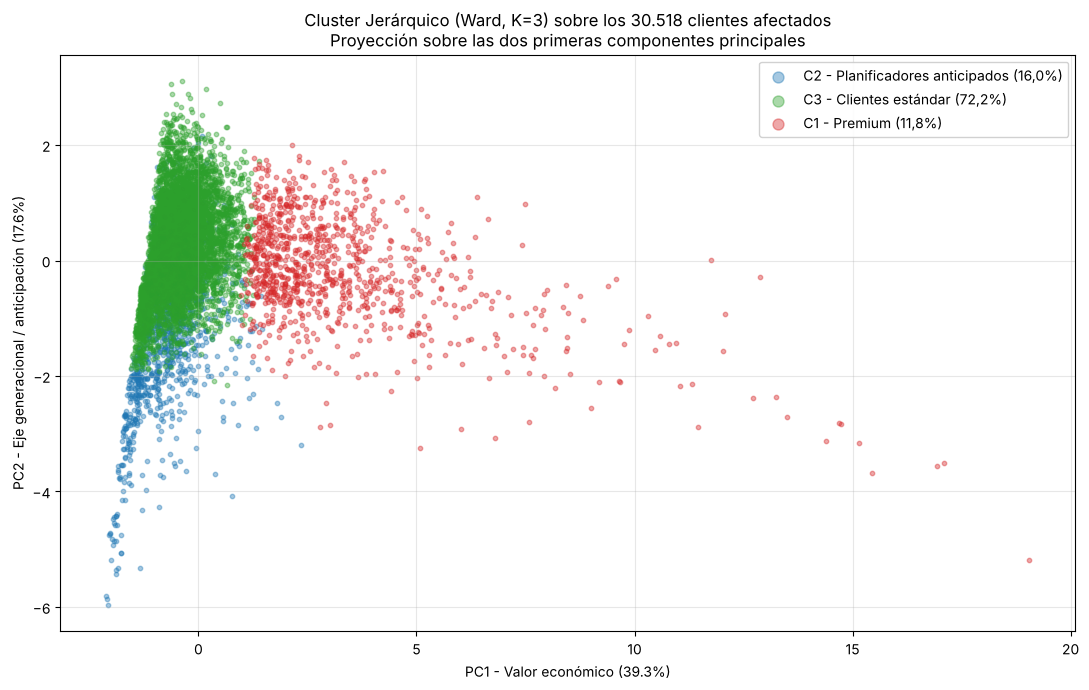

In [15]:
fig, ax = plt.subplots(figsize=(11, 7))
colors = {1: '#d62728', 2: '#1f77b4', 3: '#2ca02c'}
# Nombre de cada cluster según su perfil (no depende del número que asigne fcluster):
# Premium = mayor gasto acumulado; de los otros dos, el de mayor anticipación = Planificadores anticipados
medias = df_full.groupby('cluster_jerarquico')[['gasto_acumulado', 'anticipacion_compra_promedio']].mean()
c_premium = medias['gasto_acumulado'].idxmax()
otros = medias.drop(index=c_premium)
nombres = {c_premium: 'Premium',
           otros['anticipacion_compra_promedio'].idxmax(): 'Planificadores anticipados',
           otros['anticipacion_compra_promedio'].idxmin(): 'Clientes estándar'}
pct = df_full['cluster_jerarquico'].value_counts(normalize=True) * 100
labels_map = {c: f'C{c} - {nombres[c]} ({pct[c]:.1f}%)'.replace('.', ',') for c in nombres}
orden_plot = [c for c in sorted(nombres) if c != c_premium] + [c_premium]

# Submuestra para evitar saturación visual
sample_plot = np.random.RandomState(RANDOM_STATE).choice(
    len(proj), size=8000, replace=False)

# Graficar Premium al final para que quede visible sobre los otros
for c in orden_plot:
    mask = (df_full['cluster_jerarquico'].values[sample_plot] == c)
    ax.scatter(proj[sample_plot][mask, 0], proj[sample_plot][mask, 1],
               c=colors[c], s=10, alpha=0.4, label=labels_map[c])

ax.set_xlabel(f'PC1 - Valor económico ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 - Eje generacional / anticipación ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'Cluster Jerárquico (Ward, K=3) sobre los {n_txt} clientes afectados\n'
             'Proyección sobre las dos primeras componentes principales')
ax.legend(loc='upper right', framealpha=0.9, markerscale=2.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Sensibilidad a la muestra

El dendrograma se construye sobre una muestra de 5.000 clientes, así que conviene verificar si la segmentación depende de cuáles se eligieron. Se repite el procedimiento completo (muestra → Ward con K=3 → asignación al centroide más cercano) con diez semillas distintas y se resume cada solución, ordenando los clusters de mayor a menor gasto acumulado.

In [16]:
filas = []
for semilla in range(10):
    idx = np.random.RandomState(semilla).choice(len(X_std), size=SAMPLE_SIZE, replace=False)
    muestra = X_std.values[idx]
    lab = fcluster(linkage(muestra, method='ward'), t=3, criterion='maxclust')
    cent = np.array([muestra[lab == c].mean(axis=0) for c in np.unique(lab)])
    asignacion = cdist(X_std.values, cent).argmin(axis=1)

    perfil = (clientes.assign(c=asignacion)
              .groupby('c')[['gasto_acumulado', 'edad', 'anticipacion_compra_promedio']].mean()
              .assign(pct=pd.Series(asignacion).value_counts(normalize=True) * 100)
              .sort_values('gasto_acumulado', ascending=False))
    filas.append({
        'semilla': semilla,
        '% por cluster': ' / '.join(f'{p:.1f}' for p in perfil['pct']),
        'gasto medio (USD)': ' / '.join(f'{g:,.0f}' for g in perfil['gasto_acumulado']),
        'edad media': ' / '.join(f'{e:.0f}' for e in perfil['edad']),
        'anticipación (días)': ' / '.join(f'{a:.0f}' for a in perfil['anticipacion_compra_promedio']),
    })

pd.DataFrame(filas).set_index('semilla')

,% por cluster,gasto medio (USD),edad media,anticipación (días)
semilla,,,,
0,2.4 / 12.8 / 84.8,"51,625 / 19,455 / 3,319",39 / 40 / 37,14 / 15 / 21
1,10.3 / 78.2 / 11.6,"30,463 / 3,914 / 3,205",40 / 38 / 32,14 / 14 / 65
2,11.8 / 29.4 / 58.8,"28,393 / 4,149 / 3,385",39 / 51 / 31,15 / 15 / 24
3,2.3 / 14.0 / 83.8,"60,796 / 17,597 / 3,256",39 / 40 / 37,14 / 15 / 21
4,9.9 / 77.9 / 12.2,"31,051 / 3,947 / 3,371",40 / 38 / 34,14 / 14 / 65
5,0.0 / 9.1 / 90.9,"75,523 / 32,434 / 3,950",30 / 40 / 38,27 / 14 / 21
6,10.0 / 75.8 / 14.2,"30,820 / 3,968 / 3,241",40 / 39 / 32,14 / 13 / 60
7,1.6 / 11.6 / 86.8,"60,929 / 22,073 / 3,500",39 / 40 / 37,14 / 15 / 21
8,11.4 / 73.7 / 14.9,"28,859 / 3,764 / 3,240",40 / 39 / 33,14 / 13 / 60


**Lectura.** En todas las semillas aparece un grupo de alto gasto que corresponde al segmento Premium: abarca entre el 9 % y el 16 % de los clientes, y en tres semillas (0, 3 y 7) aparece partido en dos niveles de gasto. La división del resto, en cambio, no es estable: según la muestra, el segundo corte separa por anticipación de compra, por edad, parte al Premium en dos niveles o aísla un puñado de outliers.

Esto refuerza dos conclusiones del trabajo: el segmento Premium es una estructura real de los datos, y para segmentar al resto conviene una técnica que use el dataset completo, como K-Medias (que además se inicializa 10 veces con `n_init=10`), antes que una que dependa de una muestra.

## 11. Exportación de resultados

Se genera un archivo Excel con dos hojas:

- `clientes_clusterizados`: los 30.518 clientes con todas sus variables originales y la etiqueta de cluster asignada (`cluster_jerarquico`).
- `perfil_clusters`: perfil numérico medio de cada cluster.

In [17]:
archivo_salida = 'resultados_jerarquico.xlsx'

with pd.ExcelWriter(archivo_salida, engine='openpyxl') as writer:
    df_full.to_excel(writer, sheet_name='clientes_clusterizados', index=False)
    perfil_num.to_excel(writer, sheet_name='perfil_clusters')

print(f'Resultados exportados a {archivo_salida}')
print(f'Total clientes clusterizados: {len(df_full)}')


Resultados exportados a resultados_jerarquico.xlsx
Total clientes clusterizados: 30518
